# Task 4 - Loan Approval Prediction

The goal of this project is to build a machine learning classification model that predicts whether a loan application will be approved based on applicant financial and personal information.

The project focuses on data cleaning, exploratory data analysis, categorical encoding, classification modeling, and evaluation using precision, recall, and F1-score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import os
import joblib

In [2]:
df = pd.read_csv("data/loan_approval_dataset.csv")

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (4269, 13)

Columns:
['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [3]:
print("Data types:")
print(df.dtypes)

Data types:
loan_id                      int64
 no_of_dependents            int64
 education                     str
 self_employed                 str
 income_annum                int64
 loan_amount                 int64
 loan_term                   int64
 cibil_score                 int64
 residential_assets_value    int64
 commercial_assets_value     int64
 luxury_assets_value         int64
 bank_asset_value            int64
 loan_status                   str
dtype: object


In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# Data Cleaning

Remove leading and trailing spaces from column names

In [7]:
df.columns = df.columns.str.strip()

print("Cleaned columns:")
print(df.columns.tolist())

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Cleaned columns:
['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']

Missing values after cleaning:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Duplicate rows:
0


In [8]:
print("Education values:")
print(df["education"].value_counts())

print("\nSelf-employed values:")
print(df["self_employed"].value_counts())

print("\nLoan status values:")
print(df["loan_status"].value_counts())

Education values:
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

Self-employed values:
self_employed
Yes    2150
No     2119
Name: count, dtype: int64

Loan status values:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [9]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [10]:
asset_columns = [
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]

for column in asset_columns:
    print(f"\n{column}")
    print("Negative values:", (df[column] < 0).sum())
    print("Zero values:", (df[column] == 0).sum())


residential_assets_value
Negative values: 28
Zero values: 45

commercial_assets_value
Negative values: 0
Zero values: 107

luxury_assets_value
Negative values: 0
Zero values: 0

bank_asset_value
Negative values: 0
Zero values: 8


In [11]:
negative_residential = df[
    df["residential_assets_value"] < 0
]["residential_assets_value"]

print(negative_residential.value_counts().sort_index())

residential_assets_value
-100000    28
Name: count, dtype: int64


In [12]:
# Replace invalid negative residential asset values with 0
df.loc[
    df["residential_assets_value"] < 0,
    "residential_assets_value"
] = 0

print(
    "Negative residential asset values after cleaning:",
    (df["residential_assets_value"] < 0).sum()
)

Negative residential asset values after cleaning: 0


In [13]:
print(df.describe())

           loan_id  no_of_dependents  income_annum   loan_amount    loan_term  \
count  4269.000000       4269.000000  4.269000e+03  4.269000e+03  4269.000000   
mean   2135.000000          2.498712  5.059124e+06  1.513345e+07    10.900445   
std    1232.498479          1.695910  2.806840e+06  9.043363e+06     5.709187   
min       1.000000          0.000000  2.000000e+05  3.000000e+05     2.000000   
25%    1068.000000          1.000000  2.700000e+06  7.700000e+06     6.000000   
50%    2135.000000          3.000000  5.100000e+06  1.450000e+07    10.000000   
75%    3202.000000          4.000000  7.500000e+06  2.150000e+07    16.000000   
max    4269.000000          5.000000  9.900000e+06  3.950000e+07    20.000000   

       cibil_score  residential_assets_value  commercial_assets_value  \
count  4269.000000              4.269000e+03             4.269000e+03   
mean    599.936051              7.473272e+06             4.973155e+06   
std     172.430401              6.502878e+06       

## Exploratory Data Analysis (EDA)

In [14]:
loan_status_counts = df["loan_status"].value_counts()

print("Loan Status Counts:")
print(loan_status_counts)

print("\nLoan Status Percentages:")
print((loan_status_counts / len(df) * 100).round(2))

Loan Status Counts:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

Loan Status Percentages:
loan_status
Approved    62.22
Rejected    37.78
Name: count, dtype: float64


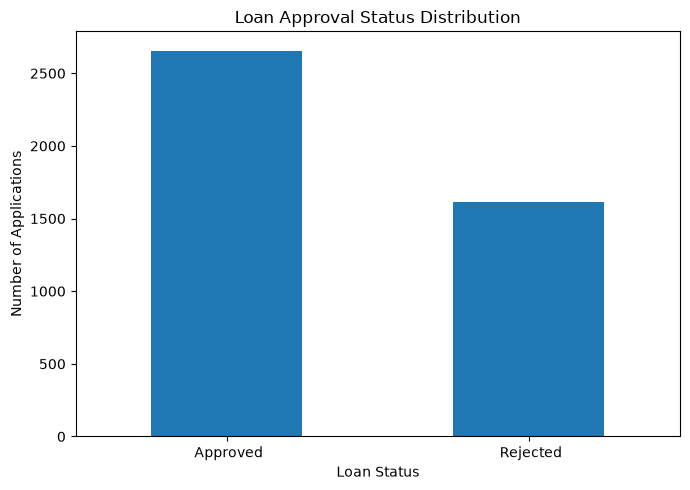

In [15]:
plt.figure(figsize=(7, 5))

loan_status_counts.plot(kind="bar")

plt.title("Loan Approval Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

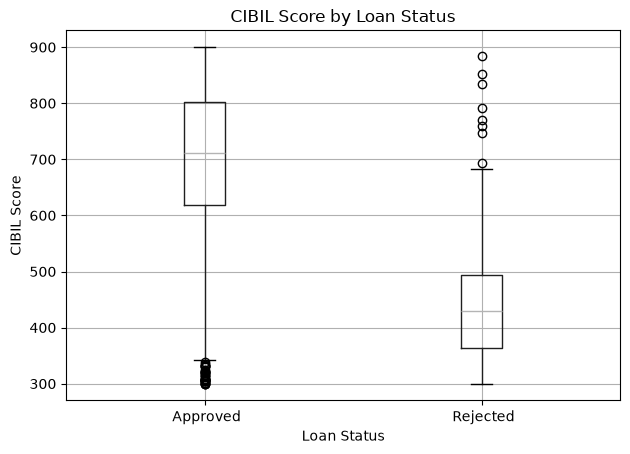

In [16]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="cibil_score",
    by="loan_status"
)

plt.title("CIBIL Score by Loan Status")
plt.suptitle("")
plt.xlabel("Loan Status")
plt.ylabel("CIBIL Score")

plt.tight_layout()
plt.show()

In [17]:
cibil_summary = df.groupby("loan_status")["cibil_score"].agg(
    ["mean", "median", "min", "max"]
)

cibil_summary

,mean,median,min,max
loan_status,,,,
Approved,703.461973,711.0,300,900
Rejected,429.468072,429.0,300,885


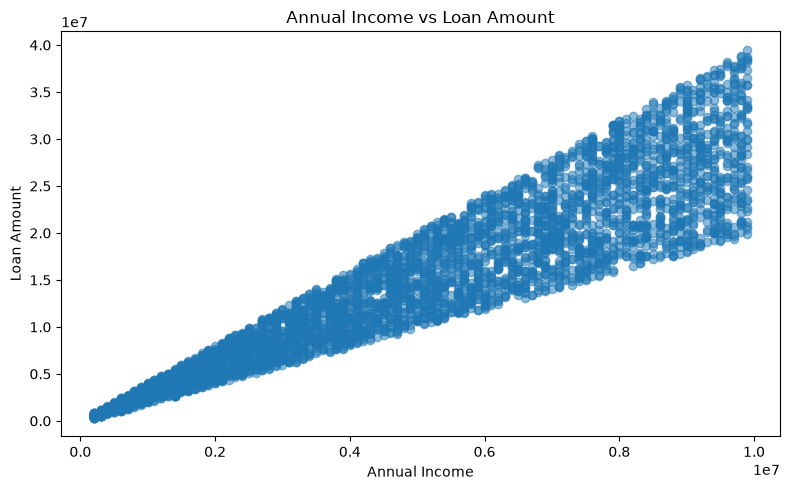

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["income_annum"],
    df["loan_amount"],
    alpha=0.5
)

plt.title("Annual Income vs Loan Amount")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")

plt.tight_layout()
plt.show()

In [19]:
correlation = df["income_annum"].corr(df["loan_amount"])

print(f"Correlation between income and loan amount: {correlation:.3f}")

Correlation between income and loan amount: 0.927


In [20]:
loan_term_status = pd.crosstab(
    df["loan_term"],
    df["loan_status"],
    normalize="index"
) * 100

print(loan_term_status)

loan_status   Approved   Rejected
loan_term                        
2            77.970297  22.029703
4            81.879195  18.120805
6            57.551020  42.448980
8            56.994819  43.005181
10           52.522936  47.477064
12           60.526316  39.473684
14           59.012346  40.987654
16           57.281553  42.718447
18           60.900474  39.099526
20           57.420925  42.579075


In [21]:
education_approval = pd.crosstab(
    df["education"],
    df["loan_status"],
    normalize="index"
) * 100

print("Approval Rate by Education:")
print(education_approval)

Approval Rate by Education:
loan_status    Approved   Rejected
education                         
Graduate      62.453358  37.546642
Not Graduate  61.976471  38.023529


In [22]:
self_employed_approval = pd.crosstab(
    df["self_employed"],
    df["loan_status"],
    normalize="index"
) * 100

print("\nApproval Rate by Self Employment:")
print(self_employed_approval)


Approval Rate by Self Employment:
loan_status     Approved   Rejected
self_employed                      
No             62.199151  37.800849
Yes            62.232558  37.767442


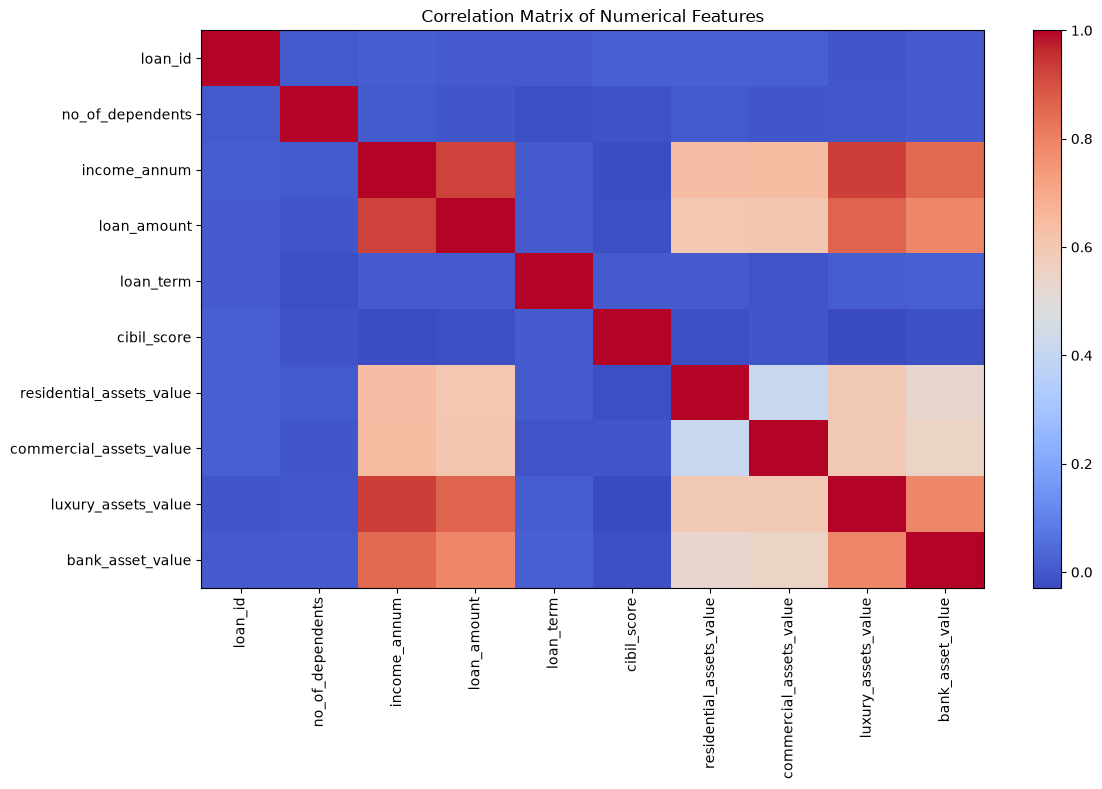

In [23]:
numeric_df = df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

In [24]:
print(correlation_matrix["loan_id"].sort_values())

luxury_assets_value        -0.000862
no_of_dependents            0.005326
loan_amount                 0.008170
loan_term                   0.009809
bank_asset_value            0.010765
income_annum                0.012592
cibil_score                 0.016323
commercial_assets_value     0.018595
residential_assets_value    0.020944
loan_id                     1.000000
Name: loan_id, dtype: float64


# Preprocessing

In [25]:
X = df.drop(columns=["loan_status", "loan_id"])
y = df["loan_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4269, 11)
y shape: (4269,)


In [26]:
X["education"] = X["education"].str.strip()
X["self_employed"] = X["self_employed"].str.strip()

In [27]:
le_education = LabelEncoder()
le_self_employed = LabelEncoder()

X["education"] = le_education.fit_transform(X["education"])
X["self_employed"] = le_self_employed.fit_transform(X["self_employed"])

print(X.head())
print(X.dtypes)

   no_of_dependents  education  self_employed  income_annum  loan_amount  \
0                 2          0              0       9600000     29900000   
1                 0          1              1       4100000     12200000   
2                 3          0              0       9100000     29700000   
3                 3          0              0       8200000     30700000   
4                 5          1              1       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_value  
0             22700

In [28]:
y = y.str.strip()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3415, 11)
X_test shape: (854, 11)
y_train shape: (3415,)
y_test shape: (854,)


In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (3415, 11)
X_test_scaled shape: (854, 11)


In [31]:
logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [32]:
y_pred = logistic_model.predict(X_test_scaled)

print("Predictions generated successfully.")
print("First 10 predictions:", y_pred[:10])

Predictions generated successfully.
First 10 predictions: ['Approved' 'Approved' 'Approved' 'Approved' 'Approved' 'Rejected'
 'Approved' 'Approved' 'Approved' 'Approved']


In [33]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label="Approved"
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label="Approved"
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Approved"
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.9227
Precision: 0.9266
Recall:    0.9510
F1-score:  0.9387


In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Approved       0.93      0.95      0.94       531
    Rejected       0.92      0.88      0.90       323

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.92       854
weighted avg       0.92      0.92      0.92       854



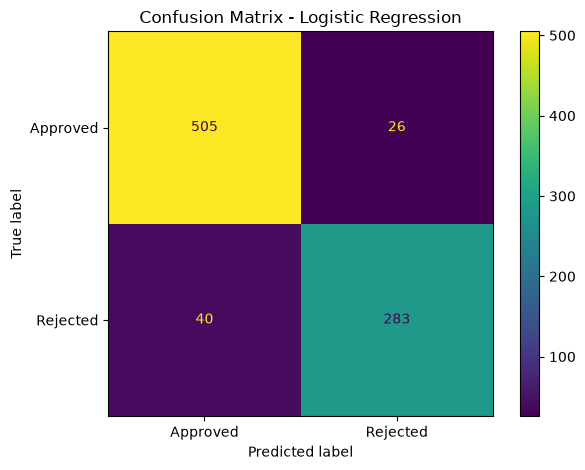

In [35]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=logistic_model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

# Bonus

In [36]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
loan_status
Approved    2125
Rejected    1290
Name: count, dtype: int64

After SMOTE:
loan_status
Rejected    2125
Approved    2125
Name: count, dtype: int64


In [37]:
smote_logistic_model = LogisticRegression(random_state=42)

smote_logistic_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_smote = smote_logistic_model.predict(X_test_scaled)

print(y_pred_smote[:10])

['Approved' 'Approved' 'Approved' 'Approved' 'Approved' 'Rejected'
 'Rejected' 'Approved' 'Approved' 'Approved']


In [38]:
accuracy_smote = accuracy_score(y_test, y_pred_smote)

precision_smote = precision_score(
    y_test,
    y_pred_smote,
    pos_label="Approved"
)

recall_smote = recall_score(
    y_test,
    y_pred_smote,
    pos_label="Approved"
)

f1_smote = f1_score(
    y_test,
    y_pred_smote,
    pos_label="Approved"
)

print("SMOTE Logistic Regression")
print(f"Accuracy:  {accuracy_smote:.4f}")
print(f"Precision: {precision_smote:.4f}")
print(f"Recall:    {recall_smote:.4f}")
print(f"F1-score:  {f1_smote:.4f}")

SMOTE Logistic Regression
Accuracy:  0.9321
Precision: 0.9471
Recall:    0.9435
F1-score:  0.9453


## SMOTE Logistic Regression

The training data was slightly imbalanced, with more approved loans than rejected loans. To handle this imbalance, SMOTE was applied to the training data only.

SMOTE creates new synthetic samples for the minority class instead of simply duplicating existing rows. After applying SMOTE, both classes had the same number of samples.

A new Logistic Regression model was then trained on the balanced training data and evaluated on the original test set.

The SMOTE model achieved better accuracy, precision, and F1-score compared with the baseline Logistic Regression model, while the recall decreased slightly.

In [39]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(
    X_train,
    y_train
)

y_pred_tree = decision_tree_model.predict(X_test)

print(y_pred_tree[:10])

['Approved' 'Approved' 'Approved' 'Rejected' 'Approved' 'Rejected'
 'Rejected' 'Approved' 'Approved' 'Approved']


In [40]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)

precision_tree = precision_score(
    y_test,
    y_pred_tree,
    pos_label="Approved"
)

recall_tree = recall_score(
    y_test,
    y_pred_tree,
    pos_label="Approved"
)

f1_tree = f1_score(
    y_test,
    y_pred_tree,
    pos_label="Approved"
)

print("Decision Tree")
print(f"Accuracy:  ️{accuracy_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall:    {recall_tree:.4f}")
print(f"F1-score:  {f1_tree:.4f}")

Decision Tree
Accuracy:  ️0.9719
Precision: 0.9703
Recall:    0.9849
F1-score:  0.9776


In [41]:
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Classification Report:
              precision    recall  f1-score   support

    Approved       0.97      0.98      0.98       531
    Rejected       0.97      0.95      0.96       323

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



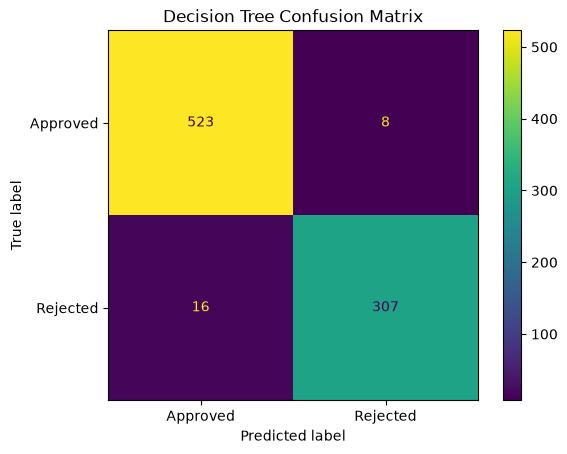

In [42]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Approved", "Rejected"]
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [43]:
y_train_pred_tree = decision_tree_model.predict(X_train)

train_accuracy_tree = accuracy_score(
    y_train,
    y_train_pred_tree
)

test_accuracy_tree = accuracy_score(
    y_test,
    y_pred_tree
)

print(f"Training Accuracy: {train_accuracy_tree:.4f}")
print(f"Test Accuracy:     {test_accuracy_tree:.4f}")

Training Accuracy: 1.0000
Test Accuracy:     0.9719


In [44]:
depths = [3, 5, 7, 10, 15, None]

results = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    results.append({
        "max_depth": depth,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred)
    })

depth_results = pd.DataFrame(results)

depth_results

,max_depth,train_accuracy,test_accuracy
0,3.0,0.962225,0.971897
1,5.0,0.972767,0.976581
2,7.0,0.982723,0.977752
3,10.0,0.993851,0.974239
4,15.0,1.000000,0.971897
5,NaN,1.000000,0.971897


In [45]:
final_model = DecisionTreeClassifier(
    max_depth=7,
    random_state=42
)

final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)

print("Final Decision Tree")
print(f"Accuracy: {accuracy_score(y_test, final_pred):.4f}")
print(f"Precision: {precision_score(y_test, final_pred, pos_label='Approved'):.4f}")
print(f"Recall: {recall_score(y_test, final_pred, pos_label='Approved'):.4f}")
print(f"F1-score: {f1_score(y_test, final_pred, pos_label='Approved'):.4f}")

Final Decision Tree
Accuracy: 0.9778
Precision: 0.9706
Recall: 0.9944
F1-score: 0.9823


In [46]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SMOTE Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_smote,
        accuracy_score(y_test, final_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred, pos_label="Approved"),
        precision_smote,
        precision_score(y_test, final_pred, pos_label="Approved")
    ],
    "Recall": [
        recall_score(y_test, y_pred, pos_label="Approved"),
        recall_smote,
        recall_score(y_test, final_pred, pos_label="Approved")
    ],
    "F1-score": [
        f1_score(y_test, y_pred, pos_label="Approved"),
        f1_smote,
        f1_score(y_test, final_pred, pos_label="Approved")
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.922717,0.926606,0.951036,0.938662
1,SMOTE Logistic Regression,0.932084,0.947070,0.943503,0.945283
2,Decision Tree,0.977752,0.970588,0.994350,0.982326


## Model Comparison and Final Model Selection

Three models were tested for the loan approval prediction task: Logistic Regression, SMOTE Logistic Regression, and Decision Tree.

The baseline Logistic Regression achieved an accuracy of 92.27%. After applying SMOTE, the Logistic Regression performance improved to 93.21% accuracy and 94.53% F1-score.

The Decision Tree achieved the best overall performance, with 97.78% accuracy and 98.23% F1-score. It also achieved a recall of 99.44% for approved loans.

Based on these results, the Decision Tree with a maximum depth of 7 was selected as the final model. This model provided the best performance on the test set while also reducing the overfitting observed in the unrestricted Decision Tree.

In [47]:
os.makedirs("artifacts", exist_ok=True)

joblib.dump(
    {
        "model": final_model,
        "features": X_train.columns.tolist(),
        "education_encoder": le_education,
        "self_employed_encoder": le_self_employed
    },
    "artifacts/loan_approval_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.
